<a href="https://colab.research.google.com/github/Haritha0105/Statistical-Learning-e21172/blob/main/Assignment_1_Basic_Notions_Of_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.

2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.

3. Explain why the two answers differ.


1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute  P(A) .

In [2]:
import numpy as np

def model_uniform_area(total_radius=10, boundary_zone=1, n_samples=1_000_000):
    u = np.random.uniform(0, 1, n_samples)
    r = total_radius * np.sqrt(u)

    # Event A: Distance from center is between 9 and 10
    successes = np.sum(r > (total_radius - boundary_zone))
    probability = successes / n_samples

    return probability

# Run simulation
p_a_1 = model_uniform_area()
print(f"Model 1 Probability P(A): {p_a_1:.4f}")

Model 1 Probability P(A): 0.1903


2. Model the experiment assuming the distance to the point from the center is chosen uniformly from  [0,10] , and the direction is chosen independently and uniformly from  [0,2π)  and compute  P(A) .

In [4]:
import numpy as np

def model_uniform_distance(total_radius=10, boundary_zone=1, n_samples=1_000_000):
    # Distance r is chosen uniformly from [0, 10]
    r = np.random.uniform(0, total_radius, n_samples)

    # Event A: Distance from center is between 9 and 10
    successes = np.sum(r > (total_radius - boundary_zone))
    probability = successes / n_samples

    return probability

# Run simulation
p_a_2 = model_uniform_distance()
print(f"Model 2 Probability P(A): {p_a_2:.4f}")

Model 2 Probability P(A): 0.0999


3. Explain why the two answers differ.

Model 1 includes the term $r$ in the density function. This correctly accounts for the fact that as $r$ increases, the "infinitesimal area" ($r \, dr \, d\theta$) increases. There is more "room" for points at the boundary, so the probability of being at the edge is higher.
<br>
<br>
Model 2 assigns equal probability to every interval of $r$ regardless of how much area that interval actually covers. This effectively "crowds" the points toward the center of the disk. In this model, the density of points per unit area is $1/r$, meaning the center is infinitely more "dense" with points than the boundary.

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

1. Method 1: Random Endpoints

In [5]:
import numpy as np

def simulation_random_endpoints(n=1_000_000):
    # Pick two random angles on the circle
    theta1 = np.random.uniform(0, 2 * np.pi, n)
    theta2 = np.random.uniform(0, 2 * np.pi, n)

    # Chord length L = 2 * R * |sin((theta1 - theta2) / 2)|
    # We use R = 1
    chord_lengths = 2 * np.abs(np.sin((theta1 - theta2) / 2))

    # Check how many exceed sqrt(3)
    successes = np.sum(chord_lengths > np.sqrt(3))
    return successes / n

print(f"Method 1 (Random Endpoints) Probability: {simulation_random_endpoints():.4f}")
# Expected Result: ~0.3333 (1/3)

Method 1 (Random Endpoints) Probability: 0.3331


2. Method 2: Random Radius

In [6]:
import numpy as np

def simulation_random_radius(n=1_000_000):
    # Pick a distance d from the center uniformly from [0, R]
    # We use R = 1
    d = np.random.uniform(0, 1, n)

    # Chord length L = 2 * sqrt(R^2 - d^2)
    chord_lengths = 2 * np.sqrt(1 - d**2)

    # Check how many exceed sqrt(3)
    successes = np.sum(chord_lengths > np.sqrt(3))
    return successes / n

print(f"Method 2 (Random Radius) Probability: {simulation_random_radius():.4f}")
# Expected Result: ~0.5000 (1/2)

Method 2 (Random Radius) Probability: 0.5003


3. Method 3: Random Midpoint

In [7]:
import numpy as np

def simulation_random_midpoint(n=1_000_000):
    # To pick a point uniformly by area, the distance r
    # must be sampled using the square root of a uniform variable.
    u = np.random.uniform(0, 1, n)
    r = np.sqrt(u)  # This represents the distance from center to midpoint

    # Chord length L = 2 * sqrt(R^2 - r^2)
    chord_lengths = 2 * np.sqrt(1 - r**2)

    # Check how many exceed sqrt(3)
    successes = np.sum(chord_lengths > np.sqrt(3))
    return successes / n

print(f"Method 3 (Random Midpoint) Probability: {simulation_random_midpoint():.4f}")
# Expected Result: ~0.2500 (1/4)

Method 3 (Random Midpoint) Probability: 0.2499


#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

The Sample SpaceThere are four equally likely outcomes for the gender of two children (ordered by birth):<br>
<br>BB (Boy, Boy)<br>BG (Boy, Girl)<br>GB (Girl, Boy)<br>GG (Girl, Girl)

<br>
Applying the ConditionThe question provides a condition:<br>
 at least one of the children is a girl. This condition eliminates the BB outcome from our list of possibilities. Our new "reduced" sample space consists of only three outcomes:<br>BG<br>GB<br>GG<br><br>Calculating the ProbabilityWe want to find the probability that both children are girls (GG) given that we are within this reduced sample space.<br>Total favorable outcomes:
  1 (the GG case)<br>Total possible outcomes remaining:
   3 (BG, GB, GG)<br>The probability is:$$P(\text{Both Girls} \mid \text{At least one Girl}) = \mathbf{\frac{1}{3}}$$

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

1. Write down the probability space  (Ω,F,P) , where  F=P(Ω)

The probability space consists of three components:Sample Space ($\Omega$): $\Omega = \{G_1, G_2, D_1, D_2\}$$\sigma$-algebra ($\mathfrak{F}$): Since $\mathfrak{F} = \mathfrak{P}(\Omega)$

(the power set), it contains all $2^4 = 16$ possible subsets of $\Omega$.$$\mathfrak{F} = \{\emptyset, \{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}, \{G_1, G_2\}, \{G_1, D_1\}, \{G_1, D_2\}, \{G_2, D_1\}, \{G_2, D_2\}, \{D_1, D_2\}, \{G_1, G_2, D_1\}, \{G_1, G_2, D_2\}, \{G_1, D_1, D_2\}, \{G_2, D_1, D_2\}, \Omega\}$$Probability Measure ($P$): Defined by the values

$P(G_1)=0.50, P(G_2)=0.20, P(D_1)=0.10, P(D_2)=0.20$.

2. Compute the  σ -algebra generated by  X , namely  σ(X) .

$X$ groups outcomes into "Good" ($0$) or "Defective" ($1$).

 The relevant sets are:$A_0 = \{s \in \Omega : X(s) = 0\} = \{G_1, G_2\}$$A_1 = \{s \in \Omega : X(s) = 1\} = \{D_1, D_2\}$$\sigma(X) = \{\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega\}$

3. Compute the  σ -algebra generated by  Y , namely  σ(Y) .

$Y$ assigns a unique value to every single outcome in $\Omega$.Since each outcome $\{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}$ is measurable individually under $Y$, the $\sigma$-algebra generated by $Y$ is the power set of $\Omega$.$\sigma(Y) = \mathfrak{P}(\Omega)$ (The same set listed in question 1).

4. Show that  σ(X)⊆σ(Y) , and explain why  Y  contains more information than  X .

Proof: Every set in $\sigma(X)$ is also a set in $\mathfrak{P}(\Omega)$. Since $\sigma(Y) = \mathfrak{P}(\Omega)$, it follows that $\sigma(X) \subseteq \sigma(Y)$.
<br><br>
Explanation: $Y$ is a finer partition of the sample space. $X$ only tells you if a part is broken; $Y$ tells you if it's broken and which machine made it. Knowing $Y$ allows you to deduce $X$, but knowing $X$ is not enough to deduce $Y$.

5. Proof: Every set in $\sigma(X)$ is also a set in $\mathfrak{P}(\Omega)$. Since $\sigma(Y) = \mathfrak{P}(\Omega)$, it follows that $\sigma(X) \subseteq \sigma(Y)$.Explanation: $Y$ is a finer partition of the sample space. $X$ only tells you if a part is broken; $Y$ tells you if it's broken and which machine made it. Knowing $Y$ allows you to deduce $X$, but knowing $X$ is not enough to deduce $Y$.

$X$ takes values in $\{0, 1\}$.
<br><br>
$P(X=0) = P(\{G_1, G_2\}) = 0.50 + 0.20 = \mathbf{0.70}$$

P(X=1) = P(\{D_1, D_2\}) = 0.10 + 0.20 = \mathbf{0.30}$

6. Find the marginal distribution of  Y .

$Y$ takes values in $\{1, 2, 3, 4\}$.
<br>
$P(Y=1) = P(G_1) = \mathbf{0.50}$

$P(Y=2) = P(G_2) = \mathbf{0.20}$

$P(Y=3) = P(D_1) = \mathbf{0.10}$

$P(Y=4) = P(D_2) = \mathbf{0.20}$

7. Compute the joint probabilities


P(X=0,Y=1),P(X=0,Y=2),P(X=1,Y=3),P(X=1,Y=4).

P(X=0, Y=1) = P(G_1) = 0.5

P(X=0, Y=2) = P(G_2) = 0.20

P(X=1, Y=3) = P(D_1) = 0.10

P(X=1, Y=4) = P(D_2) = 0.20

All other combinations like $P(X=0, Y=3)$ are $0$.

8. Compute the conditional probabilities

P(X=1∣Y=3), P(X=1∣Y=4), P(Y=3∣X=1), P(Y=4∣X=1).

Using $P(A|B) = \frac{P(A \cap B)}{P(B)}$:

$P(X=1 | Y=3) = \frac{P(D_1)}{P(D_1)} = \mathbf{1}$ (If we know $Y=3$, the item is definitely defective).

$$P(X=1 | Y=4) = \frac{P(D_2)}{P(D_2)} = \mathbf{1}$$

$$P(Y=3 | X=1) = \frac{P(D_1)}{P(X=1)} = \frac{0.10}{0.30} = \mathbf{1/3}$$


$$P(Y=4 | X=1) = \frac{P(D_2)}{P(X=1)} = \frac{0.20}{0.30} = \mathbf{2/3}$$

9. Interpret the difference between conditioning on  X  and conditioning on  Y .

Conditioning on $Y$ provides full certainty about the state of the product ($X$).

 If we know $Y$, we know exactly which machine and which quality state occurred.


Conditioning on $X$ only reduces the uncertainty slightly.

If we know an item is defective ($X=1$), we still don't know which machine produced it; we only know the relative likelihoods

10. Explain, in words, what information is available in  σ(X)  but not in  σ(Y) , and what information is available in  σ(Y)  but not in  σ(X) .



In $\sigma(X)$ but not in $\sigma(Y)$: Nothing. Since $\sigma(X) \subseteq \sigma(Y)$, all information in $X$ is already contained within $Y$.

In $\sigma(Y)$ but not in $\sigma(X)$: The Machine ID. $Y$ allows us to distinguish between Machine 1 and Machine 2 for a given quality level. $X$ treats $\{G_1, G_2\}$ as a single indistinguishable event.

11. Give a Python based visualization of the model.

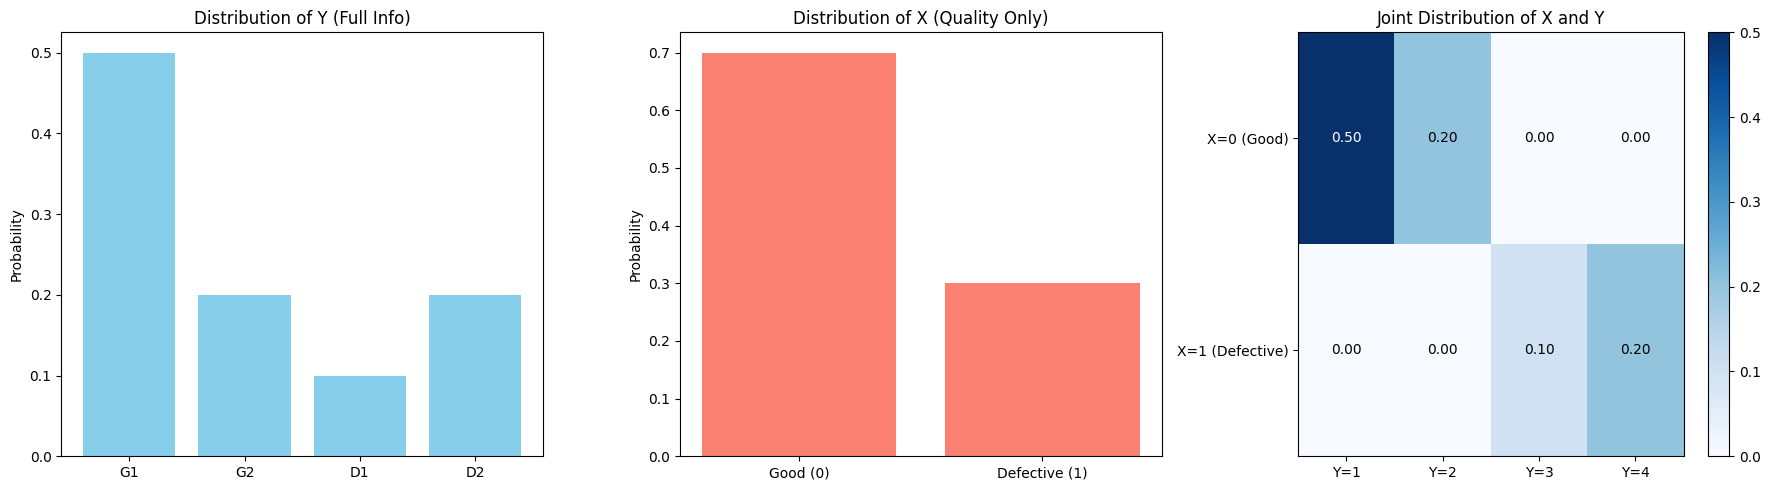

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data setup
data = {
    'Outcome': ['G1', 'G2', 'D1', 'D2'],
    'X (Quality)': [0, 0, 1, 1],
    'Y (Full)': [1, 2, 3, 4],
    'Probability': [0.50, 0.20, 0.10, 0.20]
}
df = pd.DataFrame(data)

# Create the figure with 3 subplots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Y (Detailed Information)
ax[0].bar(df['Outcome'], df['Probability'], color='skyblue')
ax[0].set_title('Distribution of Y (Full Info)')
ax[0].set_ylabel('Probability')

# 2. Plot X (Aggregated Information)
x_dist = df.groupby('X (Quality)')['Probability'].sum()
ax[1].bar(['Good (0)', 'Defective (1)'], x_dist, color='salmon')
ax[1].set_title('Distribution of X (Quality Only)')
ax[1].set_ylabel('Probability')

# 3. Plot Joint Probability Distribution (Heatmap)
# Create a matrix for the heatmap
heatmap_data = np.zeros((2, 4)) # 2 rows for X, 4 columns for Y
for i, row in df.iterrows():
    # Adjusting indices: X is 0,1. Y is 1,2,3,4 (so subtract 1)
    heatmap_data[row['X (Quality)'], row['Y (Full)'] - 1] = row['Probability']

im = ax[2].imshow(heatmap_data, cmap='Blues', aspect='auto')
ax[2].set_title('Joint Distribution of X and Y')
ax[2].set_xticks(range(4))
ax[2].set_xticklabels(['Y=1', 'Y=2', 'Y=3', 'Y=4'])
ax[2].set_yticks([0, 1])
ax[2].set_yticklabels(['X=0 (Good)', 'X=1 (Defective)'])

# Add text annotations to heatmap
for i in range(2):
    for j in range(4):
        ax[2].text(j, i, f'{heatmap_data[i, j]:.2f}', ha='center', va='center',
                   color='white' if heatmap_data[i, j] > 0.3 else 'black')

plt.colorbar(im, ax=ax[2])
plt.tight_layout()
plt.show()

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

1. Write down the probability space  (Ω,F,P)  explicitly.

The probability space is defined as:

Sample Space: $\Omega = \mathbb{R}^2$ (representing all possible pairs of temperature and pressure deviations $(t, p)$).$\sigma$-algebra: $\mathfrak{F} = \mathfrak{B}(\mathbb{R}^2)$, the Borel $\sigma$-algebra on $\mathbb{R}^2$.

Probability Measure:

 $P$ is induced by the joint density function:$$f_{T,P}(t,p) = \frac{1}{4\pi} \exp\left( -\frac{t^2}{2} - \frac{p^2}{8} \right)$$

2. Compute the  σ -algebra generated by  X , namely  σ(X) .

The random variable $X(t, p) = t$ projects the sample space onto its first component.

The $\sigma$-algebra $\sigma(X)$ consists of all sets of the form:$$\sigma(X) = \{ X^{-1}(B) : B \in \mathfrak{B}(\mathbb{R}) \} = \{ B \times \mathbb{R} : B \in \mathfrak{B}(\mathbb{R}) \}$$Visually, these are vertical strips in the $(t, p)$ plane.

3. Compute the  σ -algebra generated by  Y , namely  σ(Y) .

The random variable $Y(t, p) = (t, p)$ is the identity map on $\Omega$. Therefore, the $\sigma$-algebra it generates is the entire Borel $\sigma$-algebra of the sample space:$$\sigma(Y) = \mathfrak{B}(\mathbb{R}^2)$$

4. Show that
σ(X)⊆σ(Y),
and explain why  Y  contains more information than  X .

Proof of Inclusion:

Since $\sigma(X) = \{ B \times \mathbb{R} : B \in \mathfrak{B}(\mathbb{R}) \}$ and every set of the form $B \times \mathbb{R}$ is a Borel set in $\mathbb{R}^2$, it follows that:$$\sigma(X) \subseteq \sigma(Y)$$Explanation:

$Y$ contains more information because knowing $Y$ means you know both $T$ and $P$. Knowing $X$ only tells you $T$. In terms of $\sigma$-algebras, $\sigma(Y)$ is finer because it can resolve individual points in the plane, whereas $\sigma(X)$ can only resolve events based on the temperature (strips), leaving the pressure unknown.

5. Find the marginal density of  X .

Since $T \sim N(0, 1)$, the marginal density of $X$ (which is $T$) is:$$f_X(x) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{x^2}{2} \right)$$

6. Find the marginal density of  Y .

$Y$ represents the joint vector $(T, P)$. Since $T$ and $P$ are independent, the density of $Y$ is simply the joint density $f_{T,P}(t, p)$:$$f_Y(t, p) = \frac{1}{4\pi} \exp\left( -\frac{t^2}{2} - \frac{p^2}{8} \right)$$

7. Compute the following probabilities:


P(X≤0),

P(X>1),

P(Y∈(−∞,0]×R),

P(Y∈[−1,1]×[−2,2]).

$P(X \leq 0)$: Since $X \sim N(0, 1)$, by symmetry around the mean 0: 0.5.

$P(X > 1)$: Using the Z-table or $1 - \Phi(1) \approx 1 - 0.8413 = \mathbf{0.1587}$.

$P(Y \in (-\infty, 0] \times \mathbb{R})$: This is equivalent to $P(T \leq 0)$, which is 0.5.

$P(Y \in [-1, 1] \times [-2, 2])$: Due to independence:

$$P(-1 \leq T \leq 1) \cdot P(-2 \leq P \leq 2)$$For $T \sim N(0,1)$, $P(-1 \leq T \leq 1) \approx 0.6827$.

For $P \sim N(0,4)$, the standard deviation $\sigma = 2$. Thus $P(-2 \leq P \leq 2)$ is $P(-1\sigma \leq P \leq 1\sigma) \approx 0.6827$.

Result: $0.6827^2 \approx \mathbf{0.4661}$.

8. Compute the conditional distribution of  X  given  Y=(t,p) .

Since $X$ is a component of $Y$ ($X=t$ when $Y=(t,p)$), the value of $X$ is perfectly known given $Y$. The distribution is a Dirac delta distribution centered at $t$:$$X | Y=(t,p) \sim \delta_t$$

9. Compute the conditional distribution of  Y  given  X=t .

Given $X=t$, the first component of $Y$ is fixed at $t$. Since $T$ and $P$ are independent, the second component $P$ remains $N(0, 4)$.$$Y | X=t \sim (t, N(0, 4))$$

10. Explain, in words, what is known when one conditions on  X  and what additional information becomes available when one conditions on  Y .

Conditioning on $X$: We know the exact temperature deviation. However, we have zero information about the pressure deviation (other than its prior distribution).

Conditioning on $Y$: We have a complete snapshot of the system. Both the temperature and the pressure deviations are known exactly.

11. Show that
X=π1∘Y,


where  π1(t,p)=t ,

 and explain why this implies that  X  is a measurable function of  Y .

Proof: $X(t, p) = t$ and $\pi_1(t, p) = t$.

Thus, $X = \pi_1 \circ Y$.


Since $\pi_1$ is a projection mapping, it is continuous and therefore Borel measurable. Because $X$ can be written as a measurable function of $Y$, $X$ is $\sigma(Y)$-measurable. This confirms that all information in $X$ is already contained within $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

the joint density of  Y=(T,P)  as a contour plot or heat map;


the marginal density of  X ;


and a diagram illustrating that  σ(X)  is coarser than  σ(Y) .

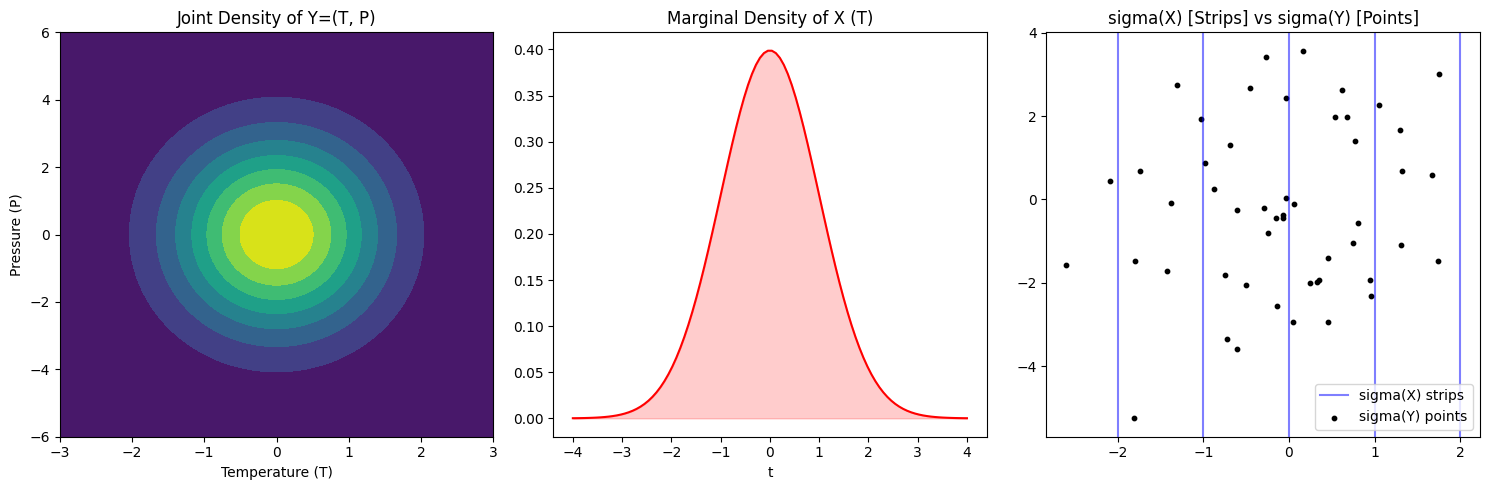

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

# 1. Joint Density of Y (Heatmap/Contour)
t = np.linspace(-3, 3, 100)
p = np.linspace(-6, 6, 100)
T, P = np.meshgrid(t, p)
pos = np.dstack((T, P))
rv = multivariate_normal([0, 0], [[1, 0], [0, 4]])

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.contourf(T, P, rv.pdf(pos), cmap='viridis')
plt.title('Joint Density of Y=(T, P)')
plt.xlabel('Temperature (T)')
plt.ylabel('Pressure (P)')

# 2. Marginal Density of X
plt.subplot(1, 3, 2)
x = np.linspace(-4, 4, 100)
plt.plot(x, norm.pdf(x, 0, 1), color='red')
plt.fill_between(x, norm.pdf(x, 0, 1), alpha=0.2, color='red')
plt.title('Marginal Density of X (T)')
plt.xlabel('t')

# 3. sigma(X) vs sigma(Y) illustration
plt.subplot(1, 3, 3)
for i in range(-2, 3):
    plt.axvline(i, color='blue', alpha=0.5, label='sigma(X) strips' if i==0 else "")
plt.scatter(np.random.normal(0, 1, 50), np.random.normal(0, 2, 50), s=10, color='black', label='sigma(Y) points')
plt.title('sigma(X) [Strips] vs sigma(Y) [Points]')
plt.legend()

plt.tight_layout()
plt.show()